 Fake News Prediction**

**Dataset:**  `WELFake_Dataset.csv`

**Kaggle Link:** https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification

In [7]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**1. Setup**

In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [9]:
# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH =  r"C:\Users\sbdsa\Downloads\udemy_ds\ML_PORJECT\fake_New_prediction\dataset\WELFake_Dataset.csv"        # update path for a different dataset
TARGET_COL = "label" # target column name

**2. Load Data & Sample**

In [10]:
data = pd.read_csv(CSV_PATH)

In [11]:
data.shape

(72134, 4)

In [12]:
data.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


Target:
- 0 = fake 
- 1 = real

In [13]:
data = data.drop(columns=["Unnamed: 0"])

In [14]:
data.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


**Get a Sample for faster processing and training**

In [15]:
# target distribution
print(data["label"].value_counts())
print("-"*40)
print(data["label"].value_counts(normalize=True)*100)

label
1    37106
0    35028
Name: count, dtype: int64
----------------------------------------
label
1   51.440
0   48.560
Name: proportion, dtype: float64


Insights: It has a nearly good balance in target columns.

In [16]:
n_samples = 10000

# separate data
df_fake = data[data["label"] == 0]
df_real = data[data["label"] == 1]

# sample
df_fake_sample = df_fake.sample(n_samples, random_state=RANDOM_STATE)
df_real_sample = df_real.sample(n_samples, random_state=RANDOM_STATE)

# Combine and shuffle
df = (
    pd.concat([df_fake_sample, df_real_sample])
      .sample(frac=1, random_state=RANDOM_STATE)
      .reset_index(drop=True)
)


In [17]:
print(df["label"].value_counts())
print("-"*40)
print(df["label"].value_counts(normalize=True)*100)

label
1    10000
0    10000
Name: count, dtype: int64
----------------------------------------
label
1   50.000
0   50.000
Name: proportion, dtype: float64


**3. Exploratory Data Analysis (EDA) & Data Preprocessing**

In [18]:
# dataframe columns
df.columns

Index(['title', 'text', 'label'], dtype='object')

In [19]:
# basic dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   19867 non-null  object
 1   text    19989 non-null  object
 2   label   20000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 468.9+ KB


In [20]:
df.isnull().sum()

title    133
text      11
label      0
dtype: int64

In [21]:
# can be dropped as less number of rows has missing values compared to the dataset size
df = df.dropna()

In [22]:
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [23]:
# target distribution
print(df["label"].value_counts())
print("="*40)
print(df["label"].value_counts(normalize=True)*100)

label
0    10000
1     9856
Name: count, dtype: int64
label
0   50.363
1   49.637
Name: proportion, dtype: float64


**Text Cleaning**

In [24]:
def clean_text(s: str) -> str:
    """
    Simple text cleaning:
    - lowercasing
    - remove URLs
    - remove HTML tags
    - keep letters/numbers and basic punctuation
    - normalize spaces
    """
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)          # URLs
    s = re.sub(r"<.*?>", " ", s)                    # HTML tags
    s = re.sub(r"[^a-z0-9\s\.\,\!\?\-\']", " ", s)   # keep basic chars
    s = re.sub(r"\s+", " ", s).strip()               # normalize spaces
    return s

In [25]:
# example 
a = "ABCabc  123*"
b = "zyxABC 999"

c = a + " " + b
print(c)

d = clean_text(c)

print(d)

ABCabc  123* zyxABC 999
abcabc 123 zyxabc 999


In [26]:
# combine title and text & apply clean_text function
df["content"] = (df["title"] + " " + df["text"]).apply(clean_text)

In [27]:
df.head()

,title,text,label,content
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breaking obama s war on cops another cop ambus...
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0,u.s. lawmakers aim to comply with iran nuclear...
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0,more than 60 killed in air strike on syrian ma...
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1,virginia republican says conservatives own chr...


In [28]:
# adding additional columns for analysis
df["title_len_chars"] = df["title"].str.len()
df["text_len_chars"] = df["text"].str.len()
df["content_len_word"] = df["content"].str.split().apply(len)

In [29]:
df.head()

,title,text,label,content,title_len_chars,text_len_chars,content_len_word
0,BREAKING…OBAMA’S WAR ON COPS: ANOTHER Cop Ambu...,"Did America really expect this racist, Communi...",1,breaking obama s war on cops another cop ambus...,134,5854,1031
1,Pennsylvania bans bias against transgender people,(Reuters) - Pennsylvania Governor Tom Wolf sig...,0,pennsylvania bans bias against transgender peo...,49,751,115
2,U.S. lawmakers aim to comply with Iran nuclear...,WASHINGTON (Reuters) - U.S. lawmakers signaled...,0,u.s. lawmakers aim to comply with iran nuclear...,55,2736,468
3,More than 60 killed in air strike on Syrian ma...,BEIRUT (Reuters) - The death toll from air str...,0,more than 60 killed in air strike on syrian ma...,55,1775,300
4,Virginia Republican Says Conservatives Own Ch...,A House Tea Party Republican declared that con...,1,virginia republican says conservatives own chr...,100,3451,593


In [30]:
num_cols = ["title_len_chars", "text_len_chars", "content_len_word"]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
title_len_chars,19856.000,76.993,25.072,4.000,62.000,73.000,89.000,286.000
text_len_chars,19856.000,3283.625,3658.956,1.000,1414.750,2435.000,4081.500,115372.000
content_len_word,19856.000,558.613,621.094,0.000,243.750,414.000,687.000,21284.000


**Data Visuzlaization**

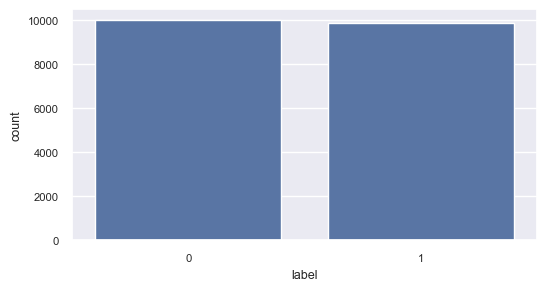

In [31]:
plt.figure(figsize=(6,3))
sns.countplot(x="label", data=df)
plt.show()

**NOTE: Almost Equal class distribution**

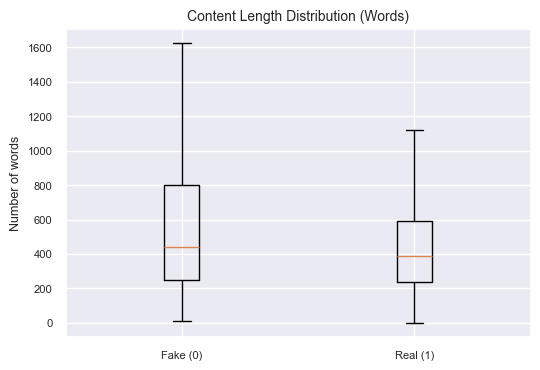

In [32]:
# text length distribution (words) - boxplot
fake_lens = df[df["label"] == 0]["content_len_word"].values
real_lens = df[df["label"] == 1]["content_len_word"].values

plt.figure(figsize=(6,4))
plt.boxplot(
    [fake_lens, real_lens],
    tick_labels=["Fake (0)", "Real (1)"],
    showfliers=False
)
plt.title("Content Length Distribution (Words)")
plt.ylabel("Number of words")
plt.show()

In [33]:
# separate features and target
X = df["content"]
y = df["label"]

In [34]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [35]:
print("\nTrain size:", len(X_train), "| Test size:", len(X_test))


Train size: 15884 | Test size: 3972


**4. Vectorization & Model Training Pipeline**

---

**What does TF-IDF mean?**

TF-IDF stands for:

Term Frequency – Inverse Document Frequency
- Term Frequency (TF): How often a word appears in a single document.
- Inverse Document Frequency (IDF): How rare that word is across all documents.

⸻

**How less important words get less importance**

Think of words like:
the, is, and, to

These words:
- Appear in almost every document
- Do not help distinguish fake vs real news

So TF-IDF does this:
- If a word appears many times in one document → its TF increases
- If the same word appears in almost all documents → its IDF becomes very small
- Final weight = TF × IDF

Result:
- Common words → low TF-IDF score
- Rare but meaningful words → high TF-IDF score

---

**Simple Intuition:**

TF-IDF rewards words that are frequent in a document but uncommon in the overall dataset. Words that appear everywhere are treated as less important.


In [36]:
model_pipeline = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            ngram_range=(1,2),
            stop_words="english",
            min_df=2
        )),
        ("model", LogisticRegression())
    ]
)

**NOTE: No scaling required**
- TF-IDF already produces normalized numerical features
- Each feature represents a word importance score, not a raw magnitude

In [37]:
# train the pipeline
model_pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


**5. Model Evaluation**

In [38]:
y_pred_train = model_pipeline.predict(X_train)
y_proba_train = model_pipeline.predict_proba(X_train)[:, 1]

acc_train = accuracy_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print("\n--- Train Metrics ---")
print(f"Accuracy : {acc_train:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm_train)

print("\nClassification Report:")
print(classification_report(y_train, y_pred_train, digits=4))


--- Train Metrics ---
Accuracy : 0.9598

Confusion Matrix [ [TN FP], [FN TP] ]:
[[7639  361]
 [ 278 7606]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9649    0.9549    0.9599      8000
           1     0.9547    0.9647    0.9597      7884

    accuracy                         0.9598     15884
   macro avg     0.9598    0.9598    0.9598     15884
weighted avg     0.9598    0.9598    0.9598     15884



In [39]:
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("\n--- Test Metrics ---")
print(f"Accuracy : {acc:.4f}")

print("\nConfusion Matrix [ [TN FP], [FN TP] ]:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


--- Test Metrics ---
Accuracy : 0.9348

Confusion Matrix [ [TN FP], [FN TP] ]:
[[1862  138]
 [ 121 1851]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9390    0.9310    0.9350      2000
           1     0.9306    0.9386    0.9346      1972

    accuracy                         0.9348      3972
   macro avg     0.9348    0.9348    0.9348      3972
weighted avg     0.9348    0.9348    0.9348      3972



**6. Build predictive system**

In [40]:
def predict_news(title, text):
    combined = clean_text(f"{title} {text}")
    prediction = model_pipeline.predict([combined])
    print(prediction)
    if prediction[0] == 1:
        print("This is a Real News 🟢")
    else:
        print("This is a Fake News 🔴")


In [41]:
# Example prediction
example_title = "Breaking: Government announces new economic policy"
example_text = "The finance minister introduced a new policy today after discussions in parliament..."
prediction = predict_news(example_title, example_text)

[1]
This is a Real News 🟢
